# 05 — Within-Crop Regression: Does Environment Predict Metabolite Chemistry?

**Approach:** Hold crop type constant (controls genetics), vary environment across RSUs.
This eliminates food-selection confounds — we're comparing butter to butter, apple to apple.

**Crops:**
- **Dairy butter — grass-fed only** (n=5): altitude → CLA. Feeding type filter applied (mixed-feed excluded).
- **Arabica coffee** (n=5): altitude → polyphenols, malic acid. Robusta excluded.
- **Olive oil — Sigoise cultivar** (n=2): precipitation → polyphenols. Same cultivar isolates terroir.
- **Golden Delicious apple** (n=4): altitude → malic acid. RSU-04 (cross-climate) excluded.
- **Coconut oil** (n=3): altitude → lauric acid (indicative only).

All regressions are bivariate (one env predictor at a time) given small n per crop.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from rsu_loader import load_all_rsus

rsus = load_all_rsus()

# Build RSU-level env DataFrame
env_rows = []
for r in rsus:
    env_rows.append({
        'region_id': r.region_id,
        'rsu_name': r.name,
        'altitude_m': getattr(r.coordinates, 'altitude_m', None),
        'temp_mean': r.climate.temperature_mean,
        'precip_mean': r.climate.precipitation_mean,
        'precip_seasonality': r.climate.precipitation_seasonality,
        'temp_seasonality': r.climate.temperature_seasonality,
        'soil_pH': r.geology.soil_pH,
    })
env_df = pd.DataFrame(env_rows).set_index('region_id')

# Build feeding_type map from RSU loader (grass-fed | mixed-feed | grain-fed | wild)
feeding_type_map = {}
for r in rsus:
    for food in r.staple_foods:
        if food.feeding_type is not None:
            feeding_type_map[(r.region_id, food.name)] = food.feeding_type

# Load metabolite matrix
mat = pd.read_csv('../data/metabolites/rsu_metabolite_matrix.csv',
                  index_col=['region_id', 'food_name'])

# Merge env features into food-level rows
region_ids = mat.index.get_level_values('region_id')
env_expanded = env_df.loc[region_ids].set_index(mat.index)
food_df = pd.concat([mat, env_expanded], axis=1)

# Add feeding_type column
food_df['feeding_type'] = food_df.index.map(lambda idx: feeding_type_map.get(idx))

print(f'Food-level rows: {len(food_df)}')
print(f'Columns: {food_df.shape[1]} (metabolites + env features + feeding_type)')
print(f'Feeding types recorded: {food_df["feeding_type"].dropna().value_counts().to_dict()}')

Food-level rows: 258
Columns: 41 (metabolites + env features + feeding_type)
Feeding types recorded: {'grass-fed': 8, 'mixed-feed': 1}


In [2]:
def bivariate_regression(ax, x, y, x_label, y_label, title,
                          point_labels=None, color='steelblue', note=''):
    """Scatter + OLS line + r²/p annotation for bivariate regression."""
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    mask = ~(np.isnan(x) | np.isnan(y))
    x_c, y_c = x[mask], y[mask]
    n = mask.sum()

    if n < 2:
        ax.text(0.5, 0.5, f'insufficient data (n={n})',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=10, color='gray')
        ax.set_title(title, fontsize=10)
        return None

    ax.scatter(x_c, y_c, color=color, s=90, zorder=3,
               edgecolors='white', linewidths=0.8)

    if point_labels is not None:
        labs = [l for l, m in zip(point_labels, mask) if m]
        for xi, yi, lab in zip(x_c, y_c, labs):
            ax.annotate(lab, (xi, yi), textcoords='offset points',
                        xytext=(7, 4), fontsize=8, color='#333333')

    slope, intercept, r, p, _ = linregress(x_c, y_c)

    if n >= 3:
        pad = (x_c.max() - x_c.min()) * 0.05
        x_line = np.linspace(x_c.min() - pad, x_c.max() + pad, 100)
        ax.plot(x_line, slope * x_line + intercept,
                '--', color='black', lw=1.4, alpha=0.55)

    sig = ' ★' if p < 0.05 else (' †' if p < 0.10 else '')
    stats = f'r² = {r**2:.3f}{sig}\np = {p:.3f}\nn = {n}'
    ax.text(0.97, 0.97, stats, transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85))

    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel(y_label, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    if note:
        ax.text(0.02, 0.02, note, transform=ax.transAxes,
                fontsize=7, color='gray', va='bottom', wrap=True)

    return {'r2': r**2, 'p': p, 'slope': slope, 'intercept': intercept, 'n': n}

## 1. Dairy butter — CLA gradient (grass-fed only)

CLA (conjugated linoleic acid) is produced in the rumen of grass-fed ruminants and deposited in milk fat.
At higher altitudes: cooler temperatures extend the grazing season, UV drives linoleic → CLA conversion,
and alpine forage has higher PUFA content from diverse highland grasses.

**Feeding type filter:** Mixed-feed/conventional butter (RSU-43) excluded from altitude regression —
feeding grain vs grass suppresses CLA regardless of altitude, masking the environmental signal.

**Prediction:** CLA increases with altitude and decreases with mean temperature (grass-fed only).

All butter RSUs:
                                                                                                                  rsu_name  altitude_m  temp_mean feeding_type  key_flavor_bioactives.conjugated_linoleic_acid
region_id food_name                                                                                                                                                                                           
RSU-04    butter                                                                                   Atlantic Western Europe         100       12.0         None                                             NaN
RSU-36    alpine butter (Alpbutter/Bergbutter)                       Alpine Central Europe (Switzerland / Austria, ~1200m)        1200        6.5    grass-fed                                            4.25
RSU-37    Irish grass-fed butter                                                                      Irish Atlantic Coast         100       10.0    grass-

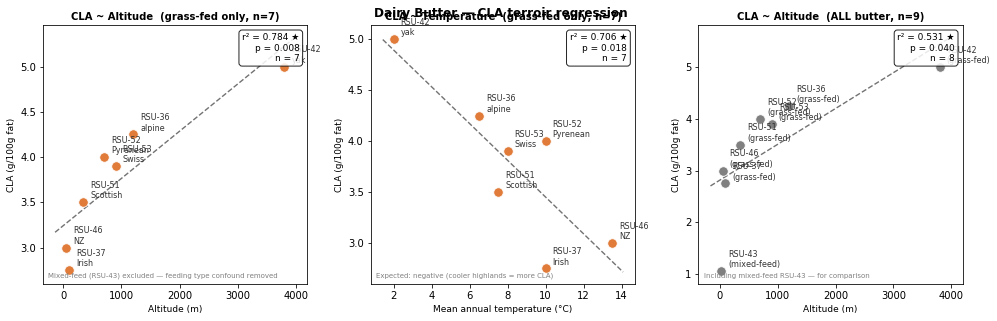

In [3]:
butter_mask = food_df.index.get_level_values('food_name').str.lower().str.contains('butter') & \
              ~food_df.index.get_level_values('food_name').str.lower().str.contains('tea|shea|peanut')
butter_df = food_df[butter_mask].copy()

# Grass-fed only: filter by feeding_type
butter_grassfed = butter_df[butter_df['feeding_type'] == 'grass-fed'].copy()

print('All butter RSUs:')
cols_show = ['rsu_name', 'altitude_m', 'temp_mean', 'feeding_type',
             'key_flavor_bioactives.conjugated_linoleic_acid']
print(butter_df[[c for c in cols_show if c in butter_df.columns]].to_string())
print(f'\nGrass-fed only: n={len(butter_grassfed)}')

labels_gf = [f"{rsu}\n{food.split()[0]}" for rsu, food in butter_grassfed.index]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
color = '#e07b39'

bivariate_regression(
    axes[0],
    x=butter_grassfed['altitude_m'],
    y=butter_grassfed['key_flavor_bioactives.conjugated_linoleic_acid'],
    x_label='Altitude (m)',
    y_label='CLA (g/100g fat)',
    title=f'CLA ~ Altitude  (grass-fed only, n={len(butter_grassfed)})',
    point_labels=labels_gf,
    color=color,
    note='Mixed-feed (RSU-43) excluded — feeding type confound removed',
)

bivariate_regression(
    axes[1],
    x=butter_grassfed['temp_mean'],
    y=butter_grassfed['key_flavor_bioactives.conjugated_linoleic_acid'],
    x_label='Mean annual temperature (°C)',
    y_label='CLA (g/100g fat)',
    title=f'CLA ~ Temperature  (grass-fed only, n={len(butter_grassfed)})',
    point_labels=labels_gf,
    color=color,
    note='Expected: negative (cooler highlands = more CLA)',
)

# Show all butter (including mixed-feed) for contrast
labels_all = [f"{rsu}\n({row['feeding_type'] or 'unknown'})"
              for (rsu, _), (_, row) in zip(butter_df.index, butter_df.iterrows())]
bivariate_regression(
    axes[2],
    x=butter_df['altitude_m'],
    y=butter_df['key_flavor_bioactives.conjugated_linoleic_acid'],
    x_label='Altitude (m)',
    y_label='CLA (g/100g fat)',
    title=f'CLA ~ Altitude  (ALL butter, n={len(butter_df)})',
    point_labels=labels_all,
    color='gray',
    note='Including mixed-feed RSU-43 — for comparison',
)

plt.suptitle('Dairy Butter — CLA terroir regression', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/metabolites/regression_butter.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Arabica coffee — altitude signal

Arabica grown at altitude: slower cherry ripening, higher sugar-to-acid conversion,
greater polyphenol accumulation (UV stress, temperature stress). Caffeine biosynthesis
may decrease at altitude (less insect pressure at high elevation).

**Robusta excluded** — different species, inherently ~2× higher caffeine regardless of environment.

**Prediction:** polyphenols increase with altitude; malic acid increases with altitude.

Arabica coffee RSUs:
                                                                                                 rsu_name  altitude_m  temp_mean  key_flavor_bioactives.polyphenol_content  organic_acids.malic_acid  key_flavor_bioactives.caffeine_concentration
region_id food_name                                                                                                                                                                                                                               
RSU-17    Arabica coffee                                                              Ethiopian Highlands        2200       16.0                                    5350.0                      1.15                                          9.25
RSU-18    Arabica coffee                                                     Colombian Andean Coffee Belt        1600       19.0                                    4600.0                      0.80                                         10.25
RSU-27 

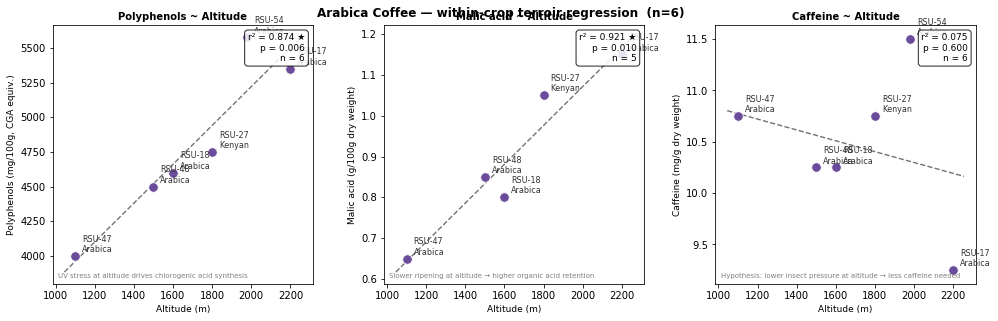

In [4]:
coffee_mask = food_df.index.get_level_values('food_name').str.lower().str.contains('arabica')
coffee_df = food_df[coffee_mask].copy()

print('Arabica coffee RSUs:')
cols_show = ['rsu_name', 'altitude_m', 'temp_mean',
             'key_flavor_bioactives.polyphenol_content',
             'organic_acids.malic_acid',
             'key_flavor_bioactives.caffeine_concentration']
print(coffee_df[[c for c in cols_show if c in coffee_df.columns]].to_string())

labels = [f"{rsu}\n{name.split()[0]}" for rsu, name in coffee_df.index]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
color = '#6b4c9a'

bivariate_regression(
    axes[0],
    x=coffee_df['altitude_m'],
    y=coffee_df['key_flavor_bioactives.polyphenol_content'],
    x_label='Altitude (m)',
    y_label='Polyphenols (mg/100g, CGA equiv.)',
    title='Polyphenols ~ Altitude',
    point_labels=labels,
    color=color,
    note='UV stress at altitude drives chlorogenic acid synthesis',
)

bivariate_regression(
    axes[1],
    x=coffee_df['altitude_m'],
    y=coffee_df['organic_acids.malic_acid'],
    x_label='Altitude (m)',
    y_label='Malic acid (g/100g dry weight)',
    title='Malic acid ~ Altitude',
    point_labels=labels,
    color=color,
    note='Slower ripening at altitude → higher organic acid retention',
)

bivariate_regression(
    axes[2],
    x=coffee_df['altitude_m'],
    y=coffee_df['key_flavor_bioactives.caffeine_concentration'],
    x_label='Altitude (m)',
    y_label='Caffeine (mg/g dry weight)',
    title='Caffeine ~ Altitude',
    point_labels=labels,
    color=color,
    note='Hypothesis: lower insect pressure at altitude → less caffeine needed',
)

plt.suptitle(f'Arabica Coffee — within-crop terroir regression  (n={len(coffee_df)})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/metabolites/regression_coffee.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Olive oil — water stress signal (Sigoise cultivar)

**Cultivar fix:** The full olive dataset mixes Sigoise (Algeria), Ravece/Ortice (Campania),
Ayvalik (Turkey), Manzanilla/Arbequina (Iberia) — each variety has a different baseline
polyphenol level. Cultivar variance swamps the environment signal.

**Sigoise-only regression (RSU-15/16):** Same cultivar, two Algerian sites — highland (1000m, 450mm precip)
vs Saharan margin (70m, 65mm precip). Same genetics, radically different water stress.

**Prediction:** polyphenols decrease with precipitation (more water = less stress = fewer polyphenols).

All olive RSUs (mixed cultivars):
                                                                                                  rsu_name  altitude_m  temp_mean  precip_mean  key_flavor_bioactives.polyphenol_content  primary_metabolites.oleic_acid
region_id food_name                                                                                                                                                                                                     
RSU-15    Sigoise olive                                                        Algerian Northern Highlands        1000       14.0          450                                     617.5                            67.0
RSU-16    Sigoise olive                                                            Algerian Saharan Margin          70       22.0           65                                     891.5                            60.5
RSU-23    olive oil (Ravece/Ortice)                                          Campania Italy Volcan

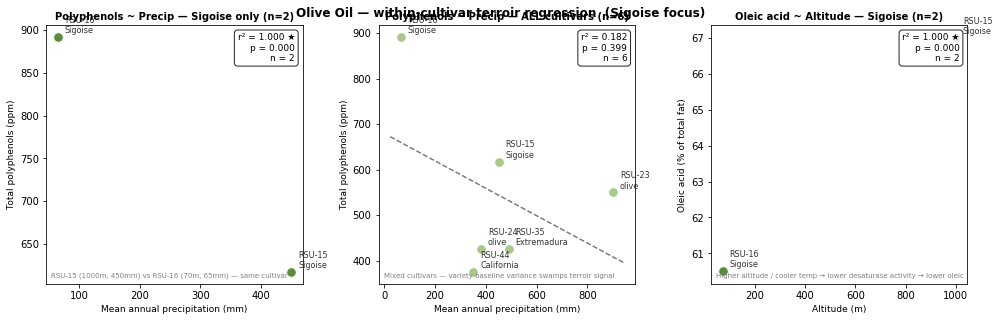

In [5]:
olive_mask = (
    food_df.index.get_level_values('food_name').str.lower().str.contains('olive') |
    food_df.index.get_level_values('food_name').str.lower().str.contains('sigoise') |
    food_df.index.get_level_values('food_name').str.lower().str.contains('evoo')
)
olive_df_all = food_df[olive_mask].copy()

# Sigoise cultivar only (RSU-15 and RSU-16) — controls genetics
sigoise_df = olive_df_all[olive_df_all.index.get_level_values('food_name').str.lower().str.contains('sigoise')].copy()

print('All olive RSUs (mixed cultivars):')
cols_show = ['rsu_name', 'altitude_m', 'temp_mean', 'precip_mean',
             'key_flavor_bioactives.polyphenol_content',
             'primary_metabolites.oleic_acid']
print(olive_df_all[[c for c in cols_show if c in olive_df_all.columns]].to_string())
print(f'\nSigoise only (same cultivar, clean terroir comparison): n={len(sigoise_df)}')

labels_sig = [f"{rsu}\n{name.split()[0]}" for rsu, name in sigoise_df.index]
labels_all = [f"{rsu}\n{name.split()[0]}" for rsu, name in olive_df_all.index]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
color_sig = '#5b8c3e'
color_all = '#a8c98a'

# Panel 1: Sigoise-only polyphenol ~ precipitation (same cultivar, cleanest comparison)
bivariate_regression(
    axes[0],
    x=sigoise_df['precip_mean'],
    y=sigoise_df['key_flavor_bioactives.polyphenol_content'],
    x_label='Mean annual precipitation (mm)',
    y_label='Total polyphenols (ppm)',
    title=f'Polyphenols ~ Precip — Sigoise only (n={len(sigoise_df)})',
    point_labels=labels_sig,
    color=color_sig,
    note='RSU-15 (1000m, 450mm) vs RSU-16 (70m, 65mm) — same cultivar',
)

# Panel 2: All olive cultivars mixed — shows why cultivar matters
bivariate_regression(
    axes[1],
    x=olive_df_all['precip_mean'],
    y=olive_df_all['key_flavor_bioactives.polyphenol_content'],
    x_label='Mean annual precipitation (mm)',
    y_label='Total polyphenols (ppm)',
    title=f'Polyphenols ~ Precip — ALL cultivars (n={len(olive_df_all)})',
    point_labels=labels_all,
    color=color_all,
    note='Mixed cultivars — variety baseline variance swamps terroir signal',
)

# Panel 3: Sigoise oleic acid ~ altitude (secondary mechanism)
bivariate_regression(
    axes[2],
    x=sigoise_df['altitude_m'],
    y=sigoise_df['primary_metabolites.oleic_acid'],
    x_label='Altitude (m)',
    y_label='Oleic acid (% of total fat)',
    title=f'Oleic acid ~ Altitude — Sigoise (n={len(sigoise_df)})',
    point_labels=labels_sig,
    color=color_sig,
    note='Higher altitude / cooler temp → lower desaturase activity → lower oleic',
)

plt.suptitle('Olive Oil — within-cultivar terroir regression  (Sigoise focus)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/metabolites/regression_olive.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Golden Delicious apple — altitude × malic acid

Same cultivar grown at four elevations across three regions. At higher altitude: cooler nights slow
malic acid degradation (malic enzyme activity is temperature-sensitive), so apples
retain more malic acid at harvest.

**RSU-04 (Atlantic France, 100m) excluded** — cross-climate comparison (Atlantic vs continental/Andean).
RSU-04 malic acid is 0.40 g/100g (higher than RSU-13 Shanxi at 600m, 0.25 g/100g) because Atlantic
temperatures differ from Shanxi temperatures at the same altitude. Including it adds cross-climate noise.

**RSU-13/14** (Shanxi, same region, same study — cleanest pair)
**RSU-49** (Chilean Maule, 800m), **RSU-50** (Turkish Isparta, 1100m) add geographic breadth.

All apple RSUs (RSU-04 excluded from regression):
                                                                        rsu_name  altitude_m  temp_mean  organic_acids.malic_acid  primary_metabolites.ascorbic_acid
region_id food_name                                                                                                                                                 
RSU-04    Golden Delicious apple                         Atlantic Western Europe         100       12.0                     0.400                               0.06
RSU-13    Golden Delicious apple                                 Shanxi Lowlands         600       13.5                     0.250                               0.10
RSU-14    Golden Delicious apple                                Shanxi Highlands        1050       10.5                     0.505                               0.28
RSU-49    Golden Delicious apple  Chilean Maule Valley (Andean foothills, ~800m)         800       12.5                     0

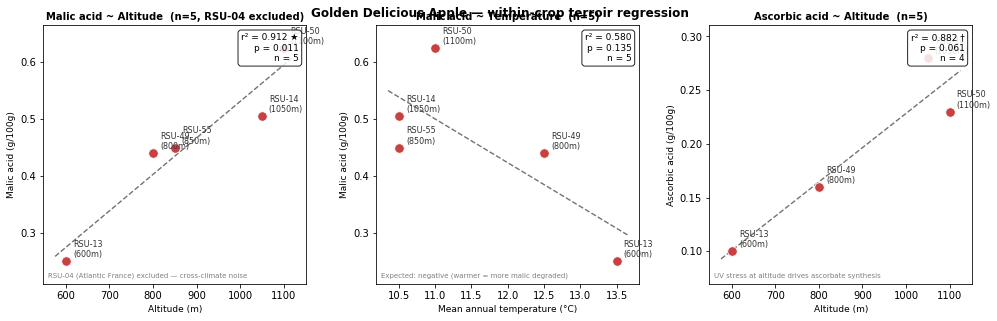

In [6]:
apple_mask = food_df.index.get_level_values('food_name').str.lower().str.contains('golden delicious')
apple_df_all = food_df[apple_mask].copy()

# Exclude RSU-04 (Atlantic France) — cross-climate noise
apple_df = apple_df_all[apple_df_all.index.get_level_values('region_id') != 'RSU-04'].copy()

print('All apple RSUs (RSU-04 excluded from regression):')
cols_show = ['rsu_name', 'altitude_m', 'temp_mean',
             'organic_acids.malic_acid', 'primary_metabolites.ascorbic_acid']
print(apple_df_all[[c for c in cols_show if c in apple_df_all.columns]].to_string())
print(f'\nRegression set (ex RSU-04): n={len(apple_df)}')

labels = [f"{rsu}\n({int(row['altitude_m'])}m)" for (rsu, _), row in apple_df.iterrows()]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
color = '#c94040'

bivariate_regression(
    axes[0],
    x=apple_df['altitude_m'],
    y=apple_df['organic_acids.malic_acid'],
    x_label='Altitude (m)', y_label='Malic acid (g/100g)',
    title=f'Malic acid ~ Altitude  (n={len(apple_df)}, RSU-04 excluded)',
    point_labels=labels, color=color,
    note='RSU-04 (Atlantic France) excluded — cross-climate noise',
)
bivariate_regression(
    axes[1],
    x=apple_df['temp_mean'],
    y=apple_df['organic_acids.malic_acid'],
    x_label='Mean annual temperature (°C)', y_label='Malic acid (g/100g)',
    title=f'Malic acid ~ Temperature  (n={len(apple_df)})',
    point_labels=labels, color=color,
    note='Expected: negative (warmer = more malic degraded)',
)
bivariate_regression(
    axes[2],
    x=apple_df['altitude_m'],
    y=apple_df['primary_metabolites.ascorbic_acid'],
    x_label='Altitude (m)', y_label='Ascorbic acid (g/100g)',
    title=f'Ascorbic acid ~ Altitude  (n={len(apple_df)})',
    point_labels=labels, color=color,
    note='UV stress at altitude drives ascorbate synthesis',
)

plt.suptitle('Golden Delicious Apple — within-crop terroir regression', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/metabolites/regression_apple.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Coconut oil — altitude × lauric acid (indicative, n=3)

Coconut oil fatty acid composition is partially temperature-sensitive: cooler
highland conditions slightly increase medium-chain fatty acid (MCFA) content,
particularly lauric acid. Effect is small compared to genetic/variety differences.

**n=3 only — treat as hypothesis-generating, not confirmatory.**

Coconut oil RSUs:
                                                                                              rsu_name  altitude_m  temp_mean  primary_metabolites.lauric_acid  primary_metabolites.oleic_acid  key_flavor_bioactives.polyphenol_content
region_id food_name                                                                                                                                                                                                                     
RSU-11    coconut oil                                                             South Indian Monsoon         100       27.0                              NaN                             NaN                                       NaN
RSU-32    coconut oil (lowland)                                   Philippine Coconut Lowlands (Quezon)          50       27.5                            46.30                            6.50                                      72.5
RSU-33    coconut oil (highland)                  

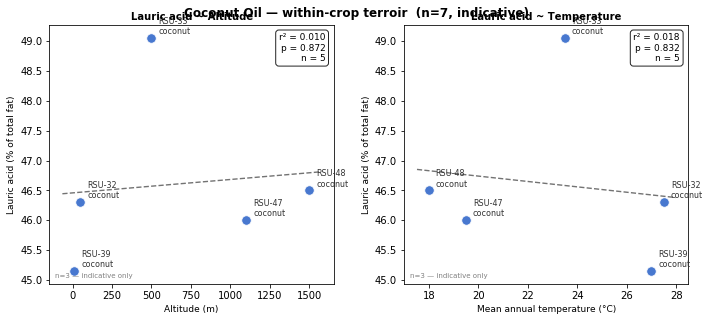

In [7]:
coconut_mask = (
    food_df.index.get_level_values('food_name').str.lower().str.contains('coconut oil') |
    food_df.index.get_level_values('food_name').str.lower().str.contains('coconut cream')
)
coconut_df = food_df[coconut_mask].copy()

print('Coconut oil RSUs:')
cols_show = ['rsu_name', 'altitude_m', 'temp_mean',
             'primary_metabolites.lauric_acid',
             'primary_metabolites.oleic_acid',
             'key_flavor_bioactives.polyphenol_content']
print(coconut_df[[c for c in cols_show if c in coconut_df.columns]].to_string())

labels = [f"{rsu}\n{name.split()[0]}" for rsu, name in coconut_df.index]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
color = '#4878cf'

bivariate_regression(
    axes[0],
    x=coconut_df['altitude_m'],
    y=coconut_df['primary_metabolites.lauric_acid'],
    x_label='Altitude (m)',
    y_label='Lauric acid (% of total fat)',
    title='Lauric acid ~ Altitude',
    point_labels=labels,
    color=color,
    note='n=3 — indicative only',
)

bivariate_regression(
    axes[1],
    x=coconut_df['temp_mean'],
    y=coconut_df['primary_metabolites.lauric_acid'],
    x_label='Mean annual temperature (°C)',
    y_label='Lauric acid (% of total fat)',
    title='Lauric acid ~ Temperature',
    point_labels=labels,
    color=color,
    note='n=3 — indicative only',
)

plt.suptitle(f'Coconut Oil — within-crop terroir  (n={len(coconut_df)}, indicative)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/metabolites/regression_coconut.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

Collect regression results across all crops and predictors.

In [8]:
def run_regression(df, x_col, y_col):
    x = pd.to_numeric(df[x_col], errors='coerce')
    y = pd.to_numeric(df[y_col], errors='coerce')
    mask = ~(x.isna() | y.isna())
    n = mask.sum()
    if n < 2:
        return {'n': n, 'r2': np.nan, 'p': np.nan, 'slope': np.nan}
    slope, intercept, r, p, _ = linregress(x[mask], y[mask])
    return {'n': n, 'r2': round(r**2, 3), 'p': round(p, 3), 'slope': round(slope, 5)}

CLA = 'key_flavor_bioactives.conjugated_linoleic_acid'
POLY = 'key_flavor_bioactives.polyphenol_content'
MALIC = 'organic_acids.malic_acid'
CAFF = 'key_flavor_bioactives.caffeine_concentration'
OLEIC = 'primary_metabolites.oleic_acid'
ASC = 'primary_metabolites.ascorbic_acid'
LAURIC = 'primary_metabolites.lauric_acid'

specs = [
    # label,              df,              x_col,       y_col,  target_label
    ('Butter (grass-fed)', butter_grassfed, 'altitude_m',  CLA,    'CLA'),
    ('Butter (grass-fed)', butter_grassfed, 'temp_mean',   CLA,    'CLA'),
    ('Butter (all)',       butter_df,       'altitude_m',  CLA,    'CLA'),
    ('Arabica coffee',     coffee_df,       'altitude_m',  POLY,   'polyphenols'),
    ('Arabica coffee',     coffee_df,       'altitude_m',  MALIC,  'malic_acid'),
    ('Arabica coffee',     coffee_df,       'altitude_m',  CAFF,   'caffeine'),
    ('Olive (Sigoise)',    sigoise_df,      'precip_mean', POLY,   'polyphenols'),
    ('Olive (all)',        olive_df_all,    'precip_mean', POLY,   'polyphenols'),
    ('Olive (all)',        olive_df_all,    'temp_mean',   OLEIC,  'oleic_acid'),
    ('Apple (ex RSU-04)', apple_df,        'altitude_m',  MALIC,  'malic_acid'),
    ('Apple (ex RSU-04)', apple_df,        'altitude_m',  ASC,    'ascorbic_acid'),
    ('Apple (ex RSU-04)', apple_df,        'temp_mean',   MALIC,  'malic_acid'),
    ('Coconut oil',        coconut_df,      'altitude_m',  LAURIC, 'lauric_acid'),
]

summary_rows = []
for label, df, pred, target, target_label in specs:
    if target not in df.columns:
        continue
    res = run_regression(df, pred, target)
    res.update({'crop': label, 'predictor': pred, 'target': target_label})
    summary_rows.append(res)

summary_df = pd.DataFrame(summary_rows)[['crop', 'predictor', 'target', 'n', 'r2', 'p', 'slope']]
summary_df['sig'] = summary_df['p'].apply(
    lambda p: '★★' if p < 0.01 else ('★' if p < 0.05 else ('†' if p < 0.10 else '')))

print(summary_df.to_string(index=False))
print('\n★★ p<0.01  ★ p<0.05  † p<0.10')

              crop   predictor        target  n    r2     p    slope sig
Butter (grass-fed)  altitude_m           CLA  7 0.784 0.008  0.00052  ★★
Butter (grass-fed)   temp_mean           CLA  7 0.706 0.018 -0.18033   ★
      Butter (all)  altitude_m           CLA  8 0.531 0.040  0.00070   ★
    Arabica coffee  altitude_m   polyphenols  6 0.874 0.006  1.39900  ★★
    Arabica coffee  altitude_m    malic_acid  5 0.921 0.010  0.00048   ★
    Arabica coffee  altitude_m      caffeine  6 0.075 0.600 -0.00053    
   Olive (Sigoise) precip_mean   polyphenols  2 1.000 0.000 -0.71169  ★★
       Olive (all) precip_mean   polyphenols  6 0.182 0.399 -0.30121    
       Olive (all)   temp_mean    oleic_acid  6 0.336 0.228 -0.75629    
 Apple (ex RSU-04)  altitude_m    malic_acid  5 0.912 0.011  0.00064   ★
 Apple (ex RSU-04)  altitude_m ascorbic_acid  4 0.882 0.061  0.00032   †
 Apple (ex RSU-04)   temp_mean    malic_acid  5 0.580 0.135 -0.07701    
       Coconut oil  altitude_m   lauric_acid  5 0.0

---
## Paper figures

Publication-ready versions saved to `../writing/`. One cell per figure.

| File | Paper figure | Description |
|---|---|---|
| `fig2_coffee.png` | Fig 2 | Coffee: CGA, malic, caffeine ~ altitude (3 panels) |
| `fig3_butter.png` | Fig 3 | Butter: CLA ~ altitude, grass-fed, country colours |
| `fig4_apple.png` | Fig 4 | Apple: malic ~ altitude, RSU-04 shown but excluded |
| `fig5_coconut.png` | Fig 5 | Coconut: lauric ~ altitude (null result) |

In [9]:
import os, warnings
warnings.filterwarnings('ignore')

WRITING = '../writing'
os.makedirs(WRITING, exist_ok=True)

def ols_line(ax, x, y, color='black', lw=1.4, alpha=0.55, extend=0.05):
    """Draw OLS regression line over existing axes range."""
    from scipy.stats import linregress
    x, y = np.asarray(x, float), np.asarray(y, float)
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() < 2:
        return None, None, None
    slope, intercept, r, p, _ = linregress(x[mask], y[mask])
    pad = (x[mask].max() - x[mask].min()) * extend
    xl = np.linspace(x[mask].min() - pad, x[mask].max() + pad, 200)
    ax.plot(xl, slope * xl + intercept, '--', color=color, lw=lw, alpha=alpha)
    return r**2, p, slope

def ann(ax, r2, p, n, slope=None, loc='upper left'):
    """Annotate axes with r², p, n (and slope if given)."""
    sig = ' ★★' if p < 0.01 else (' ★' if p < 0.05 else (' †' if p < 0.10 else ''))
    txt = f'$r^2$ = {r2:.3f}{sig}\n$p$ = {p:.3f}\n$n$ = {n}'
    if slope is not None:
        txt += f'\nslope = {slope:.4g}'
    ha = 'left' if 'left' in loc else 'right'
    va = 'top' if ('top' in loc or 'upper' in loc) else 'bottom'
    x0 = 0.03 if 'left' in loc else 0.97
    y0 = 0.97 if ('top' in loc or 'upper' in loc) else 0.03
    ax.text(x0, y0, txt, transform=ax.transAxes,
            ha=ha, va=va, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

RCPARAMS = {'font.family': 'sans-serif', 'axes.spines.top': False,
            'axes.spines.right': False, 'axes.grid': True,
            'grid.alpha': 0.35, 'grid.linestyle': ':'}
print('Helpers ready — writing to', WRITING)

Helpers ready — writing to ../writing


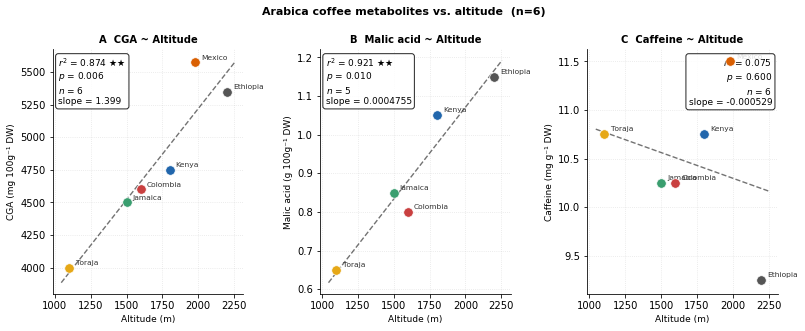

Saved → ../writing/fig2_coffee.png


In [10]:
# ── Fig 2: Arabica coffee — 3 panels ───────────────────────────────────────────
COFFEE_COLS = {
    'RSU-47': ('Toraja',   '#e6a817'),
    'RSU-48': ('Jamaica',  '#3a9e6f'),
    'RSU-18': ('Colombia', '#c94040'),
    'RSU-27': ('Kenya',    '#2166ac'),
    'RSU-54': ('Mexico',   '#d95f02'),
    'RSU-17': ('Ethiopia', '#555555'),
}

def coffee_scatter(ax, ycol, xlabel, ylabel, title, ann_loc='upper left', log_x=False):
    xs, ys = [], []
    for rsu_id, (label, color) in COFFEE_COLS.items():
        row = coffee_df[coffee_df.index.get_level_values('region_id') == rsu_id]
        if row.empty or ycol not in row.columns:
            continue
        x_raw = pd.to_numeric(row['altitude_m'], errors='coerce').iloc[0]
        y_val = pd.to_numeric(row[ycol], errors='coerce').iloc[0]
        if np.isnan(x_raw) or np.isnan(y_val):
            continue
        x_val = np.log(x_raw) if log_x else x_raw
        ax.scatter(x_val, y_val, color=color, s=90, zorder=4,
                   edgecolors='white', linewidths=0.7, label=label)
        ax.annotate(label, (x_val, y_val), textcoords='offset points',
                    xytext=(6, 3), fontsize=7.5, color='#333333')
        xs.append(x_val); ys.append(y_val)
    r2, p, slope = ols_line(ax, xs, ys, color='black')
    if r2 is not None:
        ann(ax, r2, p, len(xs), slope=slope, loc=ann_loc)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    return r2

CGA_COL   = 'key_flavor_bioactives.polyphenol_content'
MALIC_COL = 'organic_acids.malic_acid'
CAFF_COL  = 'key_flavor_bioactives.caffeine_concentration'

with plt.rc_context(RCPARAMS):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    fig.subplots_adjust(wspace=0.40)

    coffee_scatter(axes[0], CGA_COL,
                   'Altitude (m)', 'CGA (mg 100g⁻¹ DW)',
                   'A  CGA ~ Altitude')
    coffee_scatter(axes[1], MALIC_COL,
                   'Altitude (m)', 'Malic acid (g 100g⁻¹ DW)',
                   'B  Malic acid ~ Altitude')
    coffee_scatter(axes[2], CAFF_COL,
                   'Altitude (m)', 'Caffeine (mg g⁻¹ DW)',
                   'C  Caffeine ~ Altitude', ann_loc='upper right')

    fig.suptitle(f'Arabica coffee metabolites vs. altitude  (n={len(COFFEE_COLS)})',
                 fontsize=11, fontweight='bold', y=1.01)
    path = f'{WRITING}/fig2_coffee.png'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {path}')


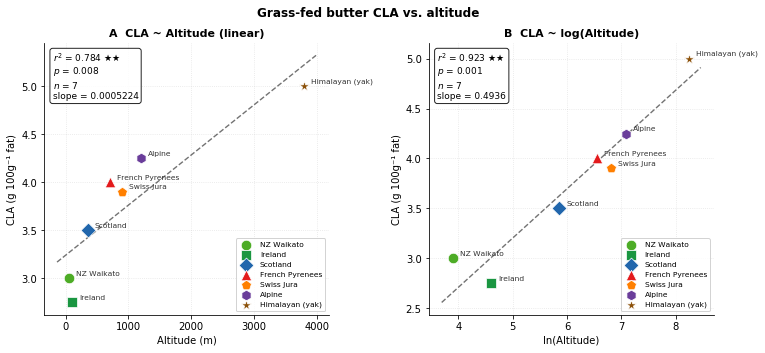

Saved → ../writing/fig3_butter.png


In [11]:
# ── Fig 3: Grass-fed butter — CLA vs altitude, linear and log comparison ────────
BUTTER_META = {
    'RSU-46': ('NZ Waikato',      '#4dac26', 'o'),
    'RSU-37': ('Ireland',         '#1a9641', 's'),
    'RSU-51': ('Scotland',        '#2166ac', 'D'),
    'RSU-52': ('French Pyrenees', '#e31a1c', '^'),
    'RSU-53': ('Swiss Jura',      '#ff7f00', 'p'),
    'RSU-36': ('Alpine',          '#6a3d9a', 'h'),
    'RSU-42': ('Himalayan (yak)', '#8c510a', '*'),
}
CLA_COL = 'key_flavor_bioactives.conjugated_linoleic_acid'

def butter_scatter(ax, log_x=False):
    xs, ys = [], []
    for rsu_id, (label, color, marker) in BUTTER_META.items():
        row = butter_grassfed[butter_grassfed.index.get_level_values('region_id') == rsu_id]
        if row.empty or CLA_COL not in row.columns:
            continue
        x_raw = pd.to_numeric(row['altitude_m'], errors='coerce').iloc[0]
        y_val = pd.to_numeric(row[CLA_COL], errors='coerce').iloc[0]
        if np.isnan(x_raw) or np.isnan(y_val):
            continue
        x_val = np.log(x_raw) if log_x else x_raw
        ax.scatter(x_val, y_val, color=color, s=110, marker=marker, zorder=4,
                   edgecolors='white', linewidths=0.7, label=label)
        ax.annotate(label, (x_val, y_val), textcoords='offset points',
                    xytext=(7, 3), fontsize=7.5, color='#333333')
        xs.append(x_val); ys.append(y_val)
    r2, p, slope = ols_line(ax, xs, ys, color='black')
    if r2 is not None:
        ann(ax, r2, p, len(xs), slope=slope, loc='upper left')
    ax.set_ylabel('CLA (g 100g⁻¹ fat)', fontsize=10)
    return r2

with plt.rc_context(RCPARAMS):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.subplots_adjust(wspace=0.35)

    butter_scatter(ax1, log_x=False)
    ax1.set_xlabel('Altitude (m)', fontsize=10)
    ax1.set_title('A  CLA ~ Altitude (linear)', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=7.5, framealpha=0.85, loc='lower right')

    butter_scatter(ax2, log_x=True)
    ax2.set_xlabel('ln(Altitude)', fontsize=10)
    ax2.set_title('B  CLA ~ log(Altitude)', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=7.5, framealpha=0.85, loc='lower right')

    fig.suptitle('Grass-fed butter CLA vs. altitude', fontsize=12, fontweight='bold')
    path = f'{WRITING}/fig3_butter.png'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {path}')


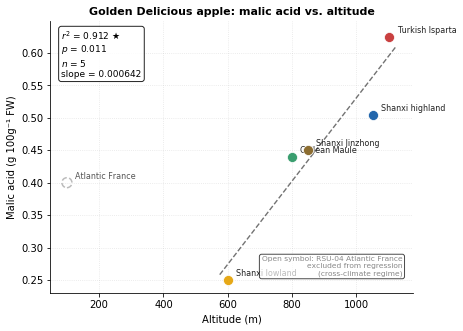

Saved → ../writing/fig4_apple.png


In [12]:
# ── Fig 4: Golden Delicious apple — malic acid ~ altitude (RSU-04 shown, excluded) ──
APPLE_META = {
    # rsu_id: (label, color, in_regression)
    'RSU-04': ('Atlantic France\n(100 m — excluded)', '#bbbbbb', False),
    'RSU-13': ('Shanxi lowland\n(600 m)',              '#e6a817', True),
    'RSU-49': ('Chilean Maule\n(800 m)',               '#3a9e6f', True),
    'RSU-55': ('Shanxi Jinzhong\n(850 m)',            '#8c6d31', True),
    'RSU-14': ('Shanxi highland\n(1050 m)',             '#2166ac', True),
    'RSU-50': ('Turkish Isparta\n(1100 m)',             '#c94040', True),
}

MALIC_COL = 'organic_acids.malic_acid'

with plt.rc_context(RCPARAMS):
    fig, ax = plt.subplots(figsize=(6.5, 5))

    xs_reg, ys_reg = [], []

    for rsu_id, (label, color, in_reg) in APPLE_META.items():
        # Pull from full apple_df_all (includes RSU-04)
        row = apple_df_all[apple_df_all.index.get_level_values('region_id') == rsu_id]
        if row.empty or MALIC_COL not in row.columns:
            continue
        x_val = pd.to_numeric(row['altitude_m'], errors='coerce').iloc[0]
        y_val = pd.to_numeric(row[MALIC_COL], errors='coerce').iloc[0]
        if np.isnan(x_val) or np.isnan(y_val):
            continue

        if in_reg:
            ax.scatter(x_val, y_val, color=color, s=100, zorder=4,
                       edgecolors='white', linewidths=0.7)
            xs_reg.append(x_val); ys_reg.append(y_val)
        else:
            # RSU-04: open symbol, dashed border, greyed label
            ax.scatter(x_val, y_val, color='none', s=100, zorder=4,
                       edgecolors=color, linewidths=1.5, linestyle='--')

        short_label = label.split('\n')[0]
        ax.annotate(short_label, (x_val, y_val),
                    textcoords='offset points', xytext=(8, 4),
                    fontsize=8, color='#555555' if not in_reg else '#222222')

    r2, p, slope = ols_line(ax, xs_reg, ys_reg)
    ann(ax, r2, p, len(xs_reg), slope=slope, loc='upper left')

    # Mark RSU-04 exclusion
    ax.text(0.97, 0.06,
            'Open symbol: RSU-04 Atlantic France\nexcluded from regression\n(cross-climate regime)',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=7.5, color='#888888',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    ax.set_xlabel('Altitude (m)', fontsize=10)
    ax.set_ylabel('Malic acid (g 100g⁻¹ FW)', fontsize=10)
    ax.set_title('Golden Delicious apple: malic acid vs. altitude', fontsize=11,
                  fontweight='bold')

    path = f'{WRITING}/fig4_apple.png'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {path}')

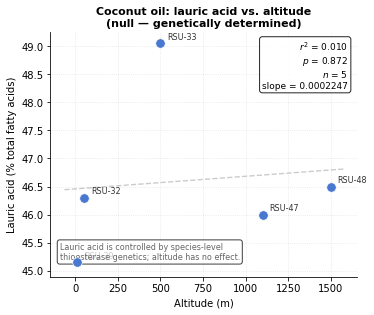

Saved → ../writing/fig5_coconut.png


In [13]:
# ── Fig 5: Coconut oil — lauric acid ~ altitude (null result) ─────────────────
LAURIC_COL = 'primary_metabolites.lauric_acid'

with plt.rc_context(RCPARAMS):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))

    xs, ys, labels_c = [], [], []
    for (rsu_id, food_name), row in coconut_df.iterrows():
        x_val = pd.to_numeric(row['altitude_m'], errors='coerce')
        y_val = pd.to_numeric(row.get(LAURIC_COL, np.nan), errors='coerce')
        if np.isnan(x_val) or np.isnan(y_val):
            continue
        ax.scatter(x_val, y_val, color='#4878cf', s=90, zorder=4,
                   edgecolors='white', linewidths=0.7)
        ax.annotate(rsu_id, (x_val, y_val),
                    textcoords='offset points', xytext=(7, 4),
                    fontsize=8, color='#333333')
        xs.append(x_val); ys.append(y_val)

    r2, p, slope = ols_line(ax, xs, ys, color='#999999', alpha=0.5)
    if r2 is not None:
        ann(ax, r2, p, len(xs), slope=slope, loc='upper right')

    ax.set_xlabel('Altitude (m)', fontsize=10)
    ax.set_ylabel('Lauric acid (% total fatty acids)', fontsize=10)
    ax.set_title('Coconut oil: lauric acid vs. altitude\n(null — genetically determined)',
                  fontsize=11, fontweight='bold')

    # Null annotation
    ax.text(0.03, 0.07,
            'Lauric acid is controlled by species-level\nthioesterase genetics; altitude has no effect.',
            transform=ax.transAxes, fontsize=8, color='#666666',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.75))

    path = f'{WRITING}/fig5_coconut.png'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {path}')

---
## Robustness checks

Three checks for the four key regressions (butter CLA, coffee CGA, coffee malic, apple malic):

1. **LOOCV** — drop one RSU at a time; report range of slope and r² across folds
2. **Bootstrap CI** — 1000 resamples with replacement; 95% CI on r² and slope
3. **Midpoint sensitivity** — 1000 runs sampling y uniformly within compiled literature ranges

In [14]:
import math
from scipy.stats import linregress

# ── Range data: {rsu_id: (x, y_low, y_high)} ─────────────────────────────────
BUTTER_RANGES = {
    'RSU-46':  (50,   2.5, 3.5),
    'RSU-37':  (100,  2.0, 3.5),
    'RSU-51':  (350,  2.8, 4.2),
    'RSU-52':  (700,  3.2, 4.8),
    'RSU-53':  (900,  3.3, 4.5),
    'RSU-36':  (1200, 3.0, 5.5),
    'RSU-42':  (3800, 3.5, 6.5),
}

COFFEE_CGA_RANGES = {
    'RSU-47': (1100, 3500, 4500),
    'RSU-48': (1500, 4200, 4800),
    'RSU-18': (1600, 3800, 5400),
    'RSU-27': (1800, 4000, 5500),
    'RSU-54': (1980, 5350, 5800),
    'RSU-17': (2200, 4500, 6200),
}

COFFEE_MALIC_RANGES = {
    'RSU-47': (1100, 0.55, 0.75),
    'RSU-48': (1500, 0.70, 1.00),
    'RSU-18': (1600, 0.60, 1.00),
    'RSU-27': (1800, 0.80, 1.30),
    'RSU-17': (2200, 0.90, 1.40),
}

APPLE_MALIC_RANGES = {
    'RSU-13': (600,  0.22, 0.28),
    'RSU-49': (800,  0.38, 0.50),
    'RSU-55': (850,  0.43, 0.47),
    'RSU-14': (1050, 0.48, 0.53),
    'RSU-50': (1100, 0.55, 0.70),
}

# Log-x versions
def log_ranges(d):
    return {k: (math.log(v[0]), v[1], v[2]) for k, v in d.items()}

BUTTER_LOG_RANGES      = log_ranges(BUTTER_RANGES)
COFFEE_CGA_LOG_RANGES  = log_ranges(COFFEE_CGA_RANGES)

REGRESSIONS = {
    'Butter CLA ~ altitude':       BUTTER_RANGES,
    'Butter CLA ~ log(altitude)':  BUTTER_LOG_RANGES,
    'Coffee CGA ~ altitude':       COFFEE_CGA_RANGES,
    'Coffee malic ~ altitude':     COFFEE_MALIC_RANGES,
    'Apple malic ~ altitude':      APPLE_MALIC_RANGES,
}

def midpoints(d):
    xs = np.array([v[0] for v in d.values()], dtype=float)
    ys = np.array([(v[1]+v[2])/2 for v in d.values()], dtype=float)
    return xs, ys

def reg(xs, ys):
    s, i, r, p, _ = linregress(xs, ys)
    return r**2, p, s

def loocv(d):
    results = []
    for drop in list(d.keys()):
        sub = {k: v for k, v in d.items() if k != drop}
        xs, ys = midpoints(sub)
        if len(xs) < 3:
            continue
        r2, p, slope = reg(xs, ys)
        results.append({'dropped': drop, 'r2': r2, 'p': p, 'slope': slope})
    return results

def bootstrap(d, n_iter=1000, seed=42):
    rng = np.random.default_rng(seed)
    xs, ys = midpoints(d)
    n = len(xs)
    r2s, slopes = [], []
    for _ in range(n_iter):
        idx = rng.integers(0, n, size=n)
        xb, yb = xs[idx], ys[idx]
        if len(np.unique(xb)) < 2:
            continue
        r2s.append(reg(xb, yb)[0]); slopes.append(reg(xb, yb)[2])
    return np.array(r2s), np.array(slopes)

def midpoint_sensitivity(d, n_iter=1000, seed=99):
    rng = np.random.default_rng(seed)
    xs   = np.array([v[0] for v in d.values()], dtype=float)
    lows = np.array([v[1] for v in d.values()], dtype=float)
    highs= np.array([v[2] for v in d.values()], dtype=float)
    r2s, ps, slopes = [], [], []
    for _ in range(n_iter):
        ys = lows + rng.random(len(lows)) * (highs - lows)
        r2, p, slope = reg(xs, ys)
        r2s.append(r2); ps.append(p); slopes.append(slope)
    return np.array(r2s), np.array(ps), np.array(slopes)

print("Helpers loaded.")
for label, d in REGRESSIONS.items():
    xs, ys = midpoints(d)
    r2, p, slope = reg(xs, ys)
    sig = '★★' if p < 0.01 else ('★' if p < 0.05 else ('†' if p < 0.10 else ''))
    print(f"  {label:<35}  n={len(d)}  r²={r2:.3f}  p={p:.3f}  {sig}")


Helpers loaded.
  Butter CLA ~ altitude                n=7  r²=0.784  p=0.008  ★★
  Butter CLA ~ log(altitude)           n=7  r²=0.923  p=0.001  ★★
  Coffee CGA ~ altitude                n=6  r²=0.874  p=0.006  ★★
  Coffee malic ~ altitude              n=5  r²=0.921  p=0.010  ★★
  Apple malic ~ altitude               n=5  r²=0.912  p=0.011  ★


In [15]:
# ── Run all three checks ─────────────────────────────────────────────────────
rob_results = {}

for label, rdict in REGRESSIONS.items():
    xs_mid, ys_mid = midpoints(rdict)
    r2_mid, p_mid, slope_mid = reg(xs_mid, ys_mid)

    loo = loocv(rdict)
    boot_r2, boot_slope = bootstrap(rdict)
    sens_r2, sens_p, sens_slope = midpoint_sensitivity(rdict)

    rob_results[label] = {
        'n': len(rdict),
        'midpoint_r2': r2_mid,
        'midpoint_p': p_mid,
        'midpoint_slope': slope_mid,
        'loocv_r2_min': min(d['r2'] for d in loo),
        'loocv_r2_max': max(d['r2'] for d in loo),
        'loocv_slope_min': min(d['slope'] for d in loo),
        'loocv_slope_max': max(d['slope'] for d in loo),
        'loocv_all_sig': all(d['p'] < 0.05 for d in loo),
        'boot_r2_ci': (np.percentile(boot_r2, 2.5), np.percentile(boot_r2, 97.5)),
        'boot_slope_ci': (np.percentile(boot_slope, 2.5), np.percentile(boot_slope, 97.5)),
        'sens_r2_median': np.median(sens_r2),
        'sens_p_pct_sig': (sens_p < 0.05).mean() * 100,
        'sens_r2_ci': (np.percentile(sens_r2, 2.5), np.percentile(sens_r2, 97.5)),
        'sens_data': (sens_r2, sens_p, sens_slope),
        'boot_data': (boot_r2, boot_slope),
        'loo_data': loo,
    }
    print(f"\n{'='*60}")
    print(f"{label}  (n={len(rdict)}, midpoint r²={r2_mid:.3f}, p={p_mid:.3f})")
    print(f"  LOOCV r²:    {rob_results[label]['loocv_r2_min']:.3f} – {rob_results[label]['loocv_r2_max']:.3f}")
    print(f"  LOOCV slope: {rob_results[label]['loocv_slope_min']:.4g} – {rob_results[label]['loocv_slope_max']:.4g}")
    print(f"  LOOCV all p<0.05: {rob_results[label]['loocv_all_sig']}")
    print(f"  Bootstrap 95% CI r²:    [{rob_results[label]['boot_r2_ci'][0]:.3f}, {rob_results[label]['boot_r2_ci'][1]:.3f}]")
    print(f"  Bootstrap 95% CI slope: [{rob_results[label]['boot_slope_ci'][0]:.4g}, {rob_results[label]['boot_slope_ci'][1]:.4g}]")
    print(f"  Midpoint sens — median r²: {rob_results[label]['sens_r2_median']:.3f}, % runs p<0.05: {rob_results[label]['sens_p_pct_sig']:.1f}%")



Butter CLA ~ altitude  (n=7, midpoint r²=0.784, p=0.008)
  LOOCV r²:    0.764 – 0.893
  LOOCV slope: 0.0004589 – 0.001217
  LOOCV all p<0.05: True
  Bootstrap 95% CI r²:    [0.717, 0.979]
  Bootstrap 95% CI slope: [0.0003667, 0.001654]
  Midpoint sens — median r²: 0.620, % runs p<0.05: 54.6%

Butter CLA ~ log(altitude)  (n=7, midpoint r²=0.923, p=0.001)
  LOOCV r²:    0.887 – 0.986
  LOOCV slope: 0.4354 – 0.6104
  LOOCV all p<0.05: True
  Bootstrap 95% CI r²:    [0.826, 0.999]
  Bootstrap 95% CI slope: [0.3445, 0.6321]
  Midpoint sens — median r²: 0.676, % runs p<0.05: 70.8%

Coffee CGA ~ altitude  (n=6, midpoint r²=0.874, p=0.006)
  LOOCV r²:    0.774 – 0.990
  LOOCV slope: 1.199 – 1.603
  LOOCV all p<0.05: True
  Bootstrap 95% CI r²:    [0.674, 1.000]
  Bootstrap 95% CI slope: [1, 2.322]
  Midpoint sens — median r²: 0.687, % runs p<0.05: 55.3%

Coffee malic ~ altitude  (n=5, midpoint r²=0.921, p=0.010)
  LOOCV r²:    0.848 – 0.970
  LOOCV slope: 0.0004516 – 0.0005192
  LOOCV all p<0

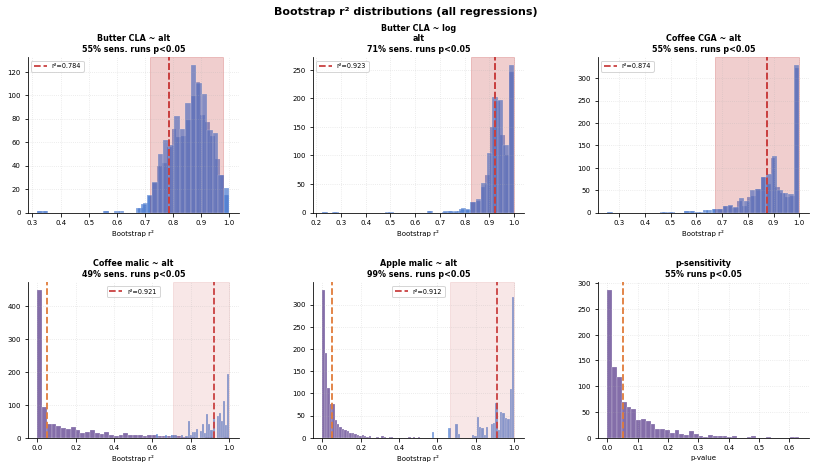

Saved → ../writing/fig_robustness.png

LOOCV detail:

Butter CLA ~ altitude
  Dropped          r²       p        slope
  RSU-46        0.764   0.023     0.000489 ★
  RSU-37        0.836   0.011    0.0004589 ★
  RSU-51        0.781   0.020    0.0005285 ★
  RSU-52        0.833   0.011    0.0005368 ★
  RSU-53        0.795   0.017    0.0005248 ★
  RSU-36        0.819   0.013    0.0005141 ★
  RSU-42        0.893   0.004     0.001217 ★★

Butter CLA ~ log(altitude)
  Dropped          r²       p        slope
  RSU-46        0.986   0.000       0.6104 ★★
  RSU-37        0.925   0.002       0.4495 ★★
  RSU-51        0.927   0.002       0.4904 ★★
  RSU-52        0.922   0.002       0.4925 ★★
  RSU-53        0.935   0.002        0.505 ★★
  RSU-36        0.917   0.003       0.4923 ★★
  RSU-42        0.887   0.005       0.4354 ★★

Coffee CGA ~ altitude
  Dropped          r²       p        slope
  RSU-47        0.774   0.049        1.486 ★
  RSU-48        0.866   0.022        1.392 ★
  RSU-18        

In [16]:
# ── Visualise: 2×3 grid — bootstrap r² dist (top) + midpoint sens p dist (bottom) ──
reg_labels = list(REGRESSIONS.keys())
n_regs = len(reg_labels)
ncols = 3
nrows = 2
# Use first 6 regressions (covers butter linear, butter log, coffee CGA linear,
# coffee CGA log, coffee malic, apple malic)

with plt.rc_context(RCPARAMS):
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7))
    fig.subplots_adjust(hspace=0.45, wspace=0.35)

    for col, label in enumerate(reg_labels[:ncols*nrows]):
        row_idx = col // ncols
        col_idx = col % ncols
        res = rob_results[label]
        boot_r2, boot_slope = res['boot_data']
        sens_r2, sens_p, _ = res['sens_data']
        r2_mid = res['midpoint_r2']
        short = label.replace(' ~ ', '\n~ ').replace('log(altitude)', 'log(alt)')

        # Row 0: Bootstrap r²
        ax = axes[0, col_idx] if row_idx == 0 else axes[row_idx, col_idx]
        # Remap: top row = cols 0-2, bottom row = cols 3-5
        ax_top = axes[0, col_idx]
        ax_bot = axes[1, col_idx]

        if row_idx == 0:
            ax_top.hist(boot_r2, bins=40, color='#4878cf', alpha=0.75,
                        edgecolor='white', linewidth=0.3)
            ax_top.axvline(r2_mid, color='#c94040', lw=1.8, linestyle='--')
            ci = res['boot_r2_ci']
            ax_top.axvspan(ci[0], ci[1], alpha=0.15, color='#c94040')
            ax_top.set_title(f'{short}\nr²={r2_mid:.3f}', fontsize=8, fontweight='bold')
            ax_top.set_xlabel('Bootstrap r²', fontsize=7)
            ax_top.tick_params(labelsize=7)

            ax_bot.hist(sens_p, bins=40, color='#5b3e8c', alpha=0.75,
                        edgecolor='white', linewidth=0.3)
            ax_bot.axvline(0.05, color='#e07b39', lw=1.8, linestyle='--')
            pct = res['sens_p_pct_sig']
            ax_bot.set_title(f'p-sensitivity\n{pct:.0f}% runs p<0.05', fontsize=8, fontweight='bold')
            ax_bot.set_xlabel('p-value', fontsize=7)
            ax_bot.tick_params(labelsize=7)

    # Handle second batch (cols 3-5 → bottom 3 slots, but we have 2 rows so
    # re-do: lay out all 6 in order across both rows)
    # Simpler: flatten axes and plot one per ax
    axes_flat = axes.flatten()
    for idx, label in enumerate(reg_labels):
        if idx >= len(axes_flat):
            break
        res = rob_results[label]
        boot_r2, _ = res['boot_data']
        sens_r2, sens_p, _ = res['sens_data']
        r2_mid = res['midpoint_r2']
        short = label.replace('altitude', 'alt').replace('log(alt)', 'log\nalt')
        ax = axes_flat[idx]
        ax.hist(boot_r2, bins=35, color='#4878cf', alpha=0.7,
                edgecolor='white', linewidth=0.3)
        ax.axvline(r2_mid, color='#c94040', lw=1.8, linestyle='--', label=f'r²={r2_mid:.3f}')
        ci = res['boot_r2_ci']
        ax.axvspan(ci[0], ci[1], alpha=0.12, color='#c94040')
        pct = res['sens_p_pct_sig']
        ax.set_title(f'{short}\n{pct:.0f}% sens. runs p<0.05', fontsize=8, fontweight='bold')
        ax.set_xlabel('Bootstrap r²', fontsize=7)
        ax.legend(fontsize=6.5)
        ax.tick_params(labelsize=7)

    fig.suptitle('Bootstrap r² distributions (all regressions)', fontsize=11, fontweight='bold')
    path_rob = f'{WRITING}/fig_robustness.png'
    fig.savefig(path_rob, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {path_rob}')

# ── LOOCV summary ─────────────────────────────────────────────────────────────
print("\nLOOCV detail:")
for label, res in rob_results.items():
    print(f"\n{label}")
    print(f"  {'Dropped':<12} {'r²':>6} {'p':>7} {'slope':>12}")
    for d in res['loo_data']:
        sig = ' ★★' if d['p'] < 0.01 else (' ★' if d['p'] < 0.05 else (' †' if d['p'] < 0.10 else ''))
        print(f"  {d['dropped']:<12} {d['r2']:>6.3f} {d['p']:>7.3f} {d['slope']:>12.4g}{sig}")
